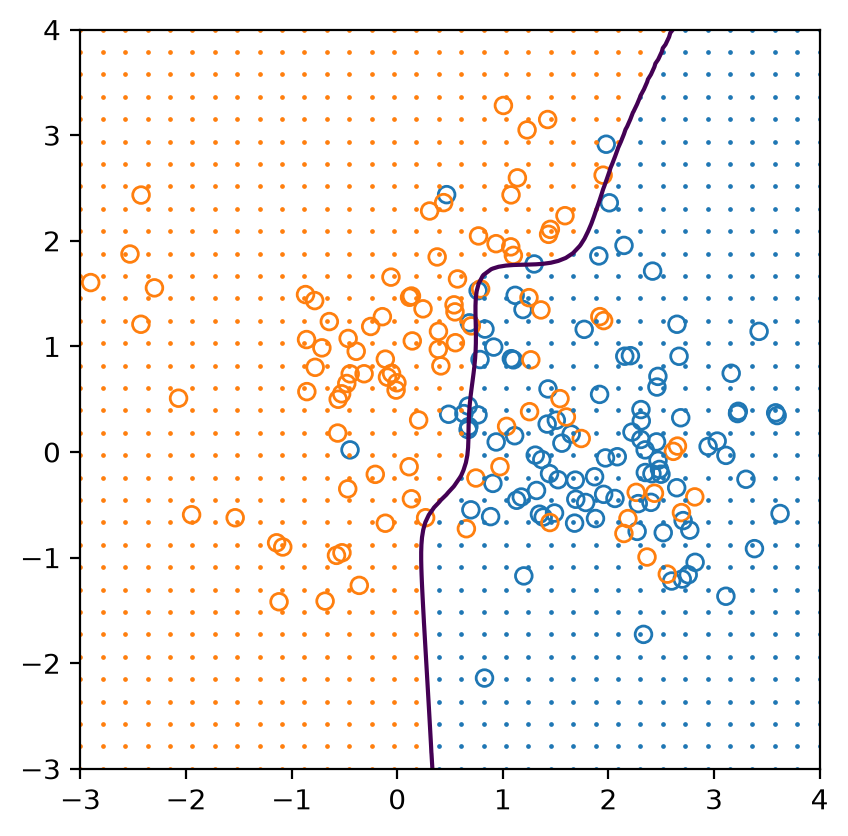

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
%config InlineBackend.figure_format = 'retina'


def gaussian(x, y, mu, sigma):
    return np.exp(-0.5 * (((x - mu[0]) / sigma) ** 2 + ((y - mu[1]) / sigma) ** 2)) / (sigma ** 2 * 2 * np.pi)


def compute_zz(xx, yy, m):
    zz = np.zeros_like(xx)
    for i in range(10):
        mu = m[i, :]
        zz += gaussian(xx, yy, mu, 1 / np.sqrt(5))
    return zz


# centers
m_blue = np.random.randn(10, 2) + [1, 0]
m_orange = np.random.randn(10, 2) + [0, 1]

# data
d_blue = m_blue[np.random.choice(10, 100), :] + np.random.randn(100,2) / np.sqrt(5)
d_orange = m_orange[np.random.choice(10, 100), :] + np.random.randn(100,2) / np.sqrt(5)

# grid
g = np.linspace(-3, 4, 100)
xx, yy = np.meshgrid(g, g)

# probabilities
zz_blue = compute_zz(xx, yy, m_blue)
zz_orange = compute_zz(xx, yy, m_orange)

# Bayesian decision boundary and decisions on a downsampled grid
zz_diff = zz_blue - zz_orange

mask_blue = zz_diff > 0
xx_blue = np.where(mask_blue, xx, np.nan)[::3,::3]
yy_blue = np.where(mask_blue, yy, np.nan)[::3,::3]
xx_orange = np.where(~mask_blue, xx, np.nan)[::3,::3]
yy_orange = np.where(~mask_blue, yy, np.nan)[::3,::3]

# plot
fig, ax = plt.subplots()

ax.contour(xx, yy, zz_diff, levels=[0])

ax.scatter(d_blue[:,0], d_blue[:,1], marker='o', facecolors='none', edgecolors='C0')
ax.scatter(d_orange[:,0], d_orange[:,1], marker='o', facecolors='none', edgecolors='C1')
ax.scatter(xx_blue, yy_blue, marker='.', color='C0', s=2)
ax.scatter(xx_orange, yy_orange, marker='.', color='C1', s=2)

ax.set_aspect('equal', 'box')
ax.set(xlim=(-3,4), ylim=(-3,4));